In [1]:
import pandas as pd

In [2]:
DATASET = '../../../datasets/libra/realdata/libra_380K.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,id_source,id_destination,cum_amount,nr_transactions,nr_alerts,nr_reports
0,0,349867,1400.00,1,0,0
1,0,351343,4000.00,1,0,0
2,0,350363,30560.00,4,0,0
3,0,349658,5200.00,2,0,0
4,1,351895,646.00,1,0,0
...,...,...,...,...,...,...
597160,385079,193633,458.00,1,0,0
597161,385081,356492,9.88,2,0,0
597162,385086,240249,12882.63,1,0,0
597163,385091,233659,230000.00,5,0,0


In [3]:
df['nr_alerts'].unique()

array([0, 1, 2, 3, 5, 6, 4])

In [4]:
import numpy as np

n_steps = 90
df["step"] = np.random.randint(0, n_steps, size=len(df))

df = df.sort_values("step").reset_index(drop=True)

In [5]:
df

,id_source,id_destination,cum_amount,nr_transactions,nr_alerts,nr_reports,step
0,352582,295650,150000.0,1,0,0,0
1,14953,377490,379.0,8,0,0,0
2,188156,356087,596.0,1,0,0,0
3,14971,349169,500.0,1,0,0,0
4,352359,128864,1.0,1,0,0,0
...,...,...,...,...,...,...,...
597160,364290,327380,23804.0,2,0,0,89
597161,364290,246205,109826.0,4,0,0,89
597162,16896,377590,500.0,1,0,0,89
597163,64250,353128,139.0,1,0,0,89


In [6]:
df.columns

Index(['id_source', 'id_destination', 'cum_amount', 'nr_transactions',
       'nr_alerts', 'nr_reports', 'step'],
      dtype='object')

In [7]:
from scipy.sparse import lil_matrix

max_account_id = max(df.id_source.max(),
                     df.id_destination.max()) + 1

print(max_account_id)

matrix = lil_matrix((max_account_id, max_account_id), dtype=int)

385100


In [8]:
from collections import defaultdict

balances = defaultdict(dict)   # {account: {step: balance}}
fraud_account = set()
users_set = set()

fraud = 0

for row in df.itertuples(index=False):
    source = int(row.id_source)
    destination = int(row.id_destination)
    step = int(row.step)
    amount = round(float(row.cum_amount), 3)  

    # Update sparse matrix
    matrix[source, destination] += amount

    # Initialize balances if user appears for the first time
    if source not in balances:
        balances[source] = {step: 0}  # First transaction, balance starts at 0
    if destination not in balances:
        balances[destination] = {step: 0}

    # Get the previous balance (default to 0 if first transaction)
    prev_balance_source = max(balances[source].values(), default=0)
    prev_balance_destination = max(balances[destination].values(), default=0)

    # Update balances for this step
    balances[source][step] = round(prev_balance_source - amount, 3)  # Source loses money
    balances[destination][step] = round(prev_balance_destination + amount, 3)  # Destination gains money

In [9]:
balances[11111]

{31: -1104.0}

In [10]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(int(balance_df.index.min()), int(balance_df.index.max()) + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_6638/2717310840.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


In [11]:
df = balance_df

In [12]:
columns_as_int = []
for col in df.columns:
    columns_as_int.append(int(str(col).strip()))

columns_as_int.sort()

df = df[columns_as_int]


In [13]:
df

,0,1,2,3,4,5,6,7,8,9,...,385090,385091,385092,385093,385094,385095,385096,385097,385098,385099
0,-4000.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-230000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
1,-4000.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-230000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
2,-4000.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-230000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
3,-4000.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-230000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
4,-4000.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-230000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,-9200.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-40000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
86,-9200.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-40000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
87,-9200.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-40000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0
88,-9200.0,-646.0,-60.49,-1884.0,-111.0,-456.2,-2975.0,-163000.0,-1726.0,-11523.86,...,250.0,-40000.0,5000.0,2001000.0,104189.81,18000.0,200.0,-389904.0,50.0,50.0


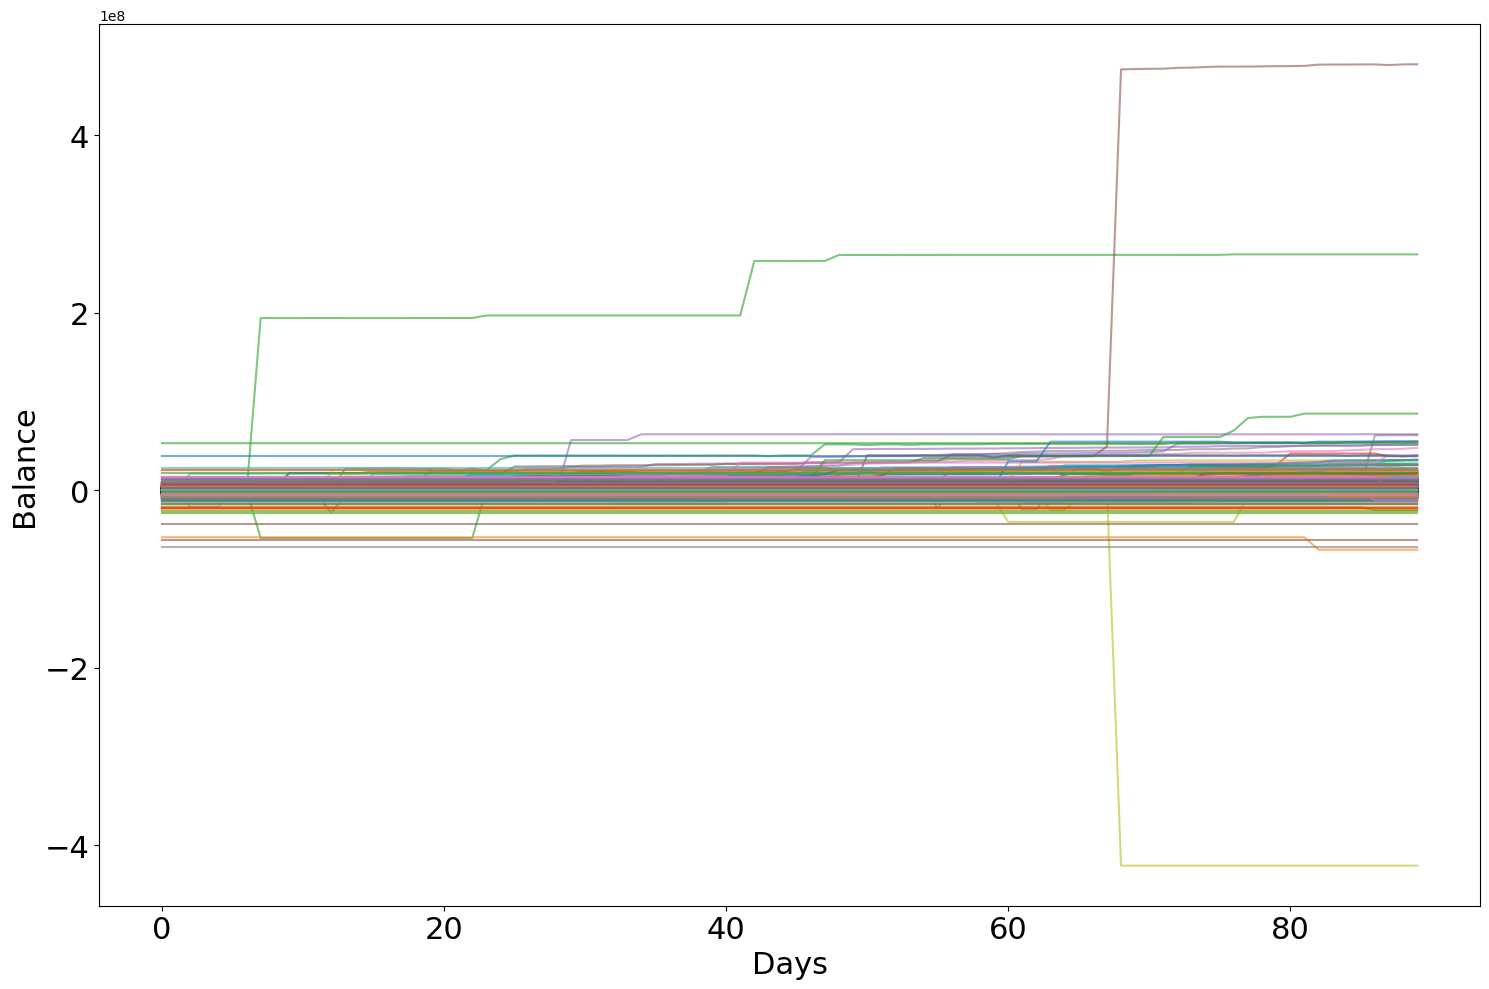

In [15]:
import matplotlib.pyplot as plt

# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    plt.plot(balance_df.index, balance_df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

In [16]:
Y = df.T.to_numpy()

In [17]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [18]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 8603502565486756.0
Min: -8602403053858980.0
Mean std per row (should be 1): 0.55
